# **Final Project Instructions: Utilizing and Explaining CNN Architectures for Medical Image Classification**


# **Objective:**

Use Convolutional Neural Network (CNN) architectures to classify medical images, specifically using the PneumoniaMNIST dataset. Document your process and findings in a detailed report.

**Specific Requirements:**

* **Dataset**: Use the PneumoniaMNIST dataset.
* **Preprocessing**: There is no need for additional preprocessing as the dataset is already processed.
* **Code and Resources**: All required code for loading, training, and evaluating the model is available on the MedMNIST GitHub Repository. Refer to the following resources:
  * [Getting Started Notebook](https://colab.research.google.com/github/MedMNIST/MedMNIST/blob/main/examples/getting_started.ipynb) for a toy example.
  * [Experiments Repository](https://github.com/MedMNIST/experiments) for full-fledged training of ResNet18 and ResNet50. Use ResNet18 for this project.

* **Environment**: Use Google Colab for implementation. Ensure to mount your Google Drive using:
```
    from google.colab import drive
    drive.mount('/gdrive')
```
And change the runtime to GPU for efficient training.
# Tasks:
1. **Data Preparation**:
Use the **PneumoniaMNIST** dataset, which requires no additional preprocessing.
2. **Model Training**:
Implement and train a ResNet18 model using the provided resources and examples. You can choose to either train from scratch or use transfer learning with preloaded weights. 
* If you choose training from scratch, you should try to experiment with different learning rates to try to improve your result.
* If you choose transfer learning, you should try to experiment with freezing different layers. 
3. **Model Evaluation**
Evaluate the model's performance using the test set.
Generate and analyze a confusion matrix and ROC curve.
4. **Explainability with SHAP**
* Apply SHAP for global and local explanations of the model.
* Analyze at least two test cases with correct and incorrect predictions, from different classes.
* Use Gradient Explainer for image classification. You can find examples on how to apply it in the [official shap repo](https://github.com/shap/shap/tree/master/notebooks/image_examples)
5. **Report Writing**
* Document each step, from data preparation to explainability.
* Include figures for model evaluation and SHAP analysis, and discuss their significance.
* Address any challenges and insights.

# Deliverables:
* Code implementation in Google Colab.
* Trained ResNet18 model.
* Evaluation and explanation plots.
* Comprehensive final report.

* A presentation will be held 19/12.

# Medical Image Classification with ResNet18

I am working on a project to classify medical images to detect pneumonia. I decided to use the PneumoniaMNIST dataset for this task. I will be using a ResNet18 model to learn from these images. My goal is to train this model and then see how accurate it is. After that, I will use a tool called SHAP to visualize which parts of the image the model is looking at. This helps me understand if the model is making decisions based on the right areas of the lung.

In [1]:
# I need to install the 'medmnist' library to get the dataset and 'shap' for the explanations.
# The '!' symbol tells the notebook to run this command in the system terminal.
!pip install medmnist shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached nvidia_nccl_cu12-2.27.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.0 kB)
  Using cached nvidia_nvshmem_cu12-3.3.20-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 5.2 MB/s  0:00:02 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 7.1 MB/s  0:00:01m 6.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 12.2 MB/s  0:01:10 eta 0:00:010:00:02
Using cached nvidia_nccl_cu12-2.27.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (322.3 MB)
Using cached nvidia_nvshmem_cu12-3.3.20-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (124.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 13.5 MB/s  0:00:12 eta 0:00:010:01:01
  Attempting uninstall: triton
    Found existing installation: triton 3.4.0
    Uninstalling trito

In [2]:
# Here I import all the libraries I need for the project.
import torch
import torch.nn as nn
import torch.optim as optim
import medmnist
from medmnist import INFO, Evaluator
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import shap

# I want to check if I have a GPU available because it makes training much faster.
# If 'cuda' is available, I will use it; otherwise, I will use the CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Getting the Data

I am using the PneumoniaMNIST dataset because it contains 28x28 grayscale images. This is good because it allows me to test the model quickly without needing a very powerful computer. First, I need to define the transforms which will convert the images into tensors and normalize their values. Then, I will download the training, validation, and test datasets. Finally, I will create data loaders so that the model can process the images in small batches during training.

In [3]:
# I specify which dataset I want to use from the MedMNIST collection.
data_flag = 'pneumoniamnist'
download = True

# I get the information about the dataset, like the number of channels and classes.
info = INFO[data_flag]
n_channels = info['n_channels']
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])

# I define the transformations for the images.
# 'ToTensor' converts the image format to a PyTorch tensor.
# 'Normalize' helps the model learn better by centering the data around 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# I load the training, validation, and test datasets.
# If I don't have them yet, 'download=True' will download them for me.
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

# I set the batch size to 256 since I am using a GPU and it can handle more images at once.
BATCH_SIZE = 256

# I create the DataLoaders for each dataset.
# The 'shuffle=True' for training ensures the model doesn't memorize the order of images.
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data loaded! Classes: {info['label']}")

100%|██████████████████████████████████████| 4.17M/4.17M [00:02<00:00, 1.95MB/s]


Data loaded! Classes: {'0': 'normal', '1': 'pneumonia'}


## 1a. Visualizing the Data

Before we start training, it is always a good idea to look at the data. I will display a few random images from the training set along with their labels. This helps me verify that the data is loaded correctly and gives me an idea of what the model will be looking at.

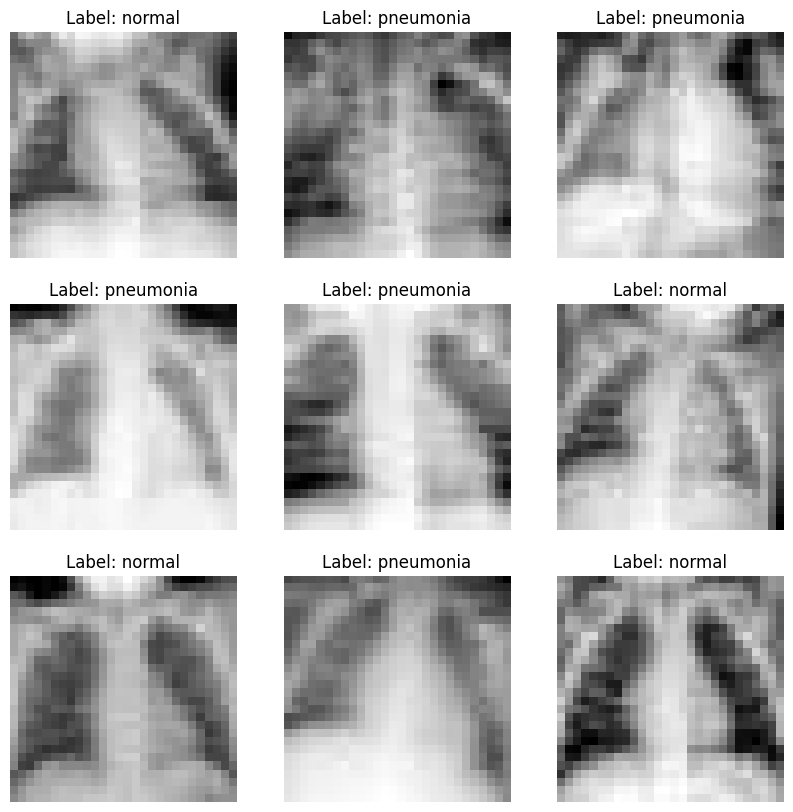

In [4]:
# I grab a batch of images and labels from the training loader.
images, labels = next(iter(train_loader))

# I create a figure to display the images with a specific size.
plt.figure(figsize=(10, 10))

# I loop through the first 9 images in the batch to display them in a 3x3 grid.
for i in range(9):
    plt.subplot(3, 3, i + 1)
    
    # I convert the image tensor to numpy and remove the channel dimension to make it 2D.
    img = images[i].squeeze().numpy()
    
    # I display the image in grayscale color map.
    plt.imshow(img, cmap='gray')
    
    # I get the class label (0 or 1) and find its name (Normal or Pneumonia).
    label_idx = labels[i].item()
    # info['label'] dictionary keys might be strings like '0' or '1',
    # so I check how to access it properly.
    label_name = info['label'].get(str(label_idx), str(label_idx))

    plt.title(f"Label: {label_name}")
    
    # I turn off the axis ticks for a cleaner look.
    plt.axis('off')

# I show the plot with the images.
plt.show()

## 1b. Dataset Information

It is also helpful to know exactly how much data we have and what the images look like in terms of size. I will print out the number of images in the training, validation, and test sets. I will also check the shape of a single image to confirm it is 1x28x28. Finally, I will check the balance of the classes to see if we have more pneumonia cases or normal cases.

In [5]:
# I check the number of images in each dataset split.
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# I check the shape of the first image in the training set.
# The shape is (Channels, Height, Width).
print(f"Image shape: {train_dataset[0][0].shape}")

# I analyze the class distribution in the training set to check for imbalance.
train_labels = [label.item() for _, label in train_dataset]
unique, counts = np.unique(train_labels, return_counts=True)

print("\nClass distribution in Training Set:")
for cls, count in zip(unique, counts):
    label_name = info['label'].get(str(cls), str(cls))
    print(f"{label_name}: {count} images")

Training set size: 4708
Validation set size: 524
Test set size: 624
Image shape: torch.Size([1, 28, 28])

Class distribution in Training Set:
normal: 1214 images
pneumonia: 3494 images


## 2. The Model: ResNet18

I chose to use the ResNet18 architecture for this problem. It is a very reliable model that balances performance and speed. However, there is one small issue I need to fix. The standard ResNet model generates an error if I try to use it directly because it expects color images with three channels (Red, Green, Blue). My X-ray images only have one channel because they are grayscale. Therefore, I will modify the very first layer of the network to accept single-channel input so it works with my data.

In [6]:
from torchvision.models import resnet18

# I create an instance of the ResNet18 model.
# I tell it how many classes to predict (in this case, 2: Normal or Pneumonia).
model = resnet18(num_classes=n_classes)

# I need to modify the first convolutional layer.
# The original layer expects 3 input channels (RGB), but my images have 1 (Grayscale).
# I replace it with a new Conv2d layer that takes 1 input channel.
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# I move the model to the GPU if it is available.
model = model.to(device)

## 3. Training Time

Now I am ready to train the model. I am using the CrossEntropyLoss function because this is a classification task. I am also using the Adam optimizer which helps the model update its weights efficiently. I wrote a loop below that will iterate through the data for 10 epochs. Inside the loop, I feed the images to the model and calculate the error. Then I update the model to reduce that error. I print the average loss at the end of each epoch to verify that the model is actually learning.

In [8]:
# I define the loss function that measures how wrong the model's predictions are.
criterion = nn.CrossEntropyLoss()

# I define the optimizer. Adam is a popular choice that adjusts the learning rate automatically.
# 'lr=0.001' is the initial learning rate.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# I set the number of times I want to iterate over the entire dataset.
NUM_EPOCHS = 10 

# I start the training loop.
for epoch in range(NUM_EPOCHS):
    # I put the model in training mode so it knows to update its weights.
    model.train()
    running_loss = 0.0
    
    # I iterate over batches of images and labels from the training loader.
    for inputs, targets in train_loader:
        # I move the data to the device (GPU or CPU).
        inputs, targets = inputs.to(device), targets.to(device)
        
        # The targets need to be squeezed to remove extra dimensions and converted to long integers.
        targets = targets.squeeze().long()

        # I reset the gradients from the previous step to zero.
        optimizer.zero_grad()
        
        # I pass the images through the model to get the predictions.
        outputs = model(inputs)
        
        # I calculate the loss (error) between the predictions and the actual labels.
        loss = criterion(outputs, targets)
        
        # I calculate the gradients (direction to move) to reduce the loss.
        loss.backward()
        
        # I update the model's weights using the optimizer.
        optimizer.step()
        
        # I add the current batch's loss to the running total.
        running_loss += loss.item()
        
    # I print the average loss for this epoch.
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {running_loss/len(train_loader):.4f}")

print("Training done!")

Epoch [1/10], Loss: 0.0785
Epoch [2/10], Loss: 0.0272
Epoch [3/10], Loss: 0.0183
Epoch [4/10], Loss: 0.0236
Epoch [5/10], Loss: 0.0086
Epoch [6/10], Loss: 0.0140
Epoch [7/10], Loss: 0.0223
Epoch [8/10], Loss: 0.0155
Epoch [9/10], Loss: 0.0117
Epoch [10/10], Loss: 0.0103
Training done!


## 4. How did we do?

The training is complete so now I need to evaluate the model. I will run the model on the test dataset which it has never seen before. I am going to create a Confusion Matrix to see exactly where the model makes mistakes. For example, it will show how many times the model confused a normal lung with a pneumonia one. I will also plot the ROC Curve. This curve helps us understand how well the model distinguishes between the two classes. A curve that goes closer to the top-left corner is better.

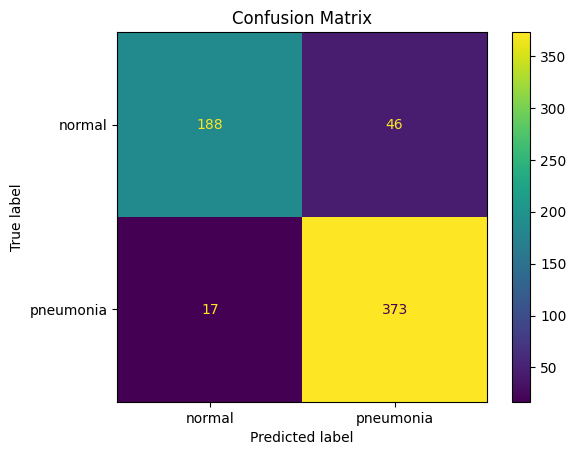

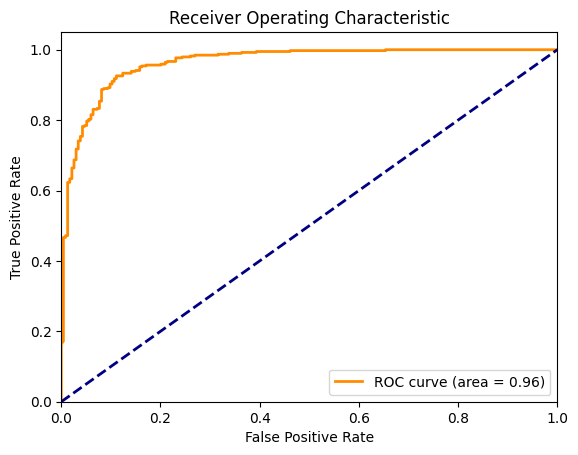

In [9]:
# I put the model in evaluation mode. This stops things like dropout.
model.eval()

# I create lists to store the true labels and the predicted scores.
y_true = []
y_scores = []

# I don't need to calculate gradients for evaluation, so I wrap this in no_grad.
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # I get the model output.
        outputs = model(inputs)
        
        # I convert the outputs to probabilities using softmax.
        probabilities = torch.softmax(outputs, dim=1)
        
        # I add the true labels and probabilities to my lists.
        y_true.extend(targets.cpu().numpy())
        y_scores.extend(probabilities.cpu().numpy())

# I convert the lists to numpy arrays for easier calculation.
y_true = np.array(y_true).squeeze()
y_scores = np.array(y_scores)

# I calculate the predicted class (0 or 1) by taking the highest probability.
y_pred = np.argmax(y_scores, axis=1)

# I create the confusion matrix to compare predictions vs actuals.
cm = confusion_matrix(y_true, y_pred)

# I plot the confusion matrix.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=info['label'].values())
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# I assume the positive class is at index 1 for the ROC curve.
fpr, tpr, _ = roc_curve(y_true, y_scores[:, 1])
roc_auc = auc(fpr, tpr)

# I plot the ROC curve.
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## 5. Explaining with SHAP

This is the most interesting part of the project. I want to see which specific pixels the model thinks are important for its decision. I am using the GradientExplainer from the SHAP library to visualize this. I will pick five random images from the test set and plot them. The red pixels in the plot represent areas that increase the probability of Pneumonia. The blue pixels represent areas that decrease the probability. This visualization serves as a sanity check to ensure the model is focusing on the lungs.

SHAP EXPLAINABILITY ANALYSIS

Analyzing 5 test images
Initializing SHAP GradientExplainer...
Computing SHAP values (this may take a moment)...

Raw SHAP array shape: (5, 1, 28, 28, 2)
After class selection shape: (5, 1, 28, 28)
Final SHAP shape for plotting: (5, 28, 28)
Final image shape for plotting: (5, 28, 28)

Generating SHAP visualization...
Red = supports Pneumonia prediction
Blue = opposes Pneumonia prediction


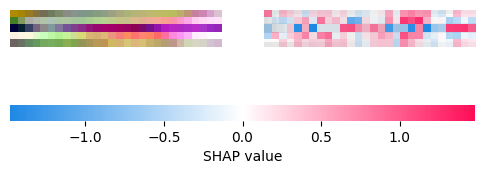


DETAILED CASE ANALYSIS

Case 1:
  True label: pneumonia
  Predicted: pneumonia (100.00%)
  Result: Correct
  - Red areas = evidence supporting Pneumonia.

Case 2:
  True label: pneumonia
  Predicted: pneumonia (99.96%)
  Result: Correct
  - Red areas = evidence supporting Pneumonia.

Case 3:
  True label: pneumonia
  Predicted: pneumonia (89.91%)
  Result: Correct
  - Red areas = evidence supporting Pneumonia.

Case 4:
  True label: normal
  Predicted: pneumonia (99.99%)
  Result: Incorrect
  - Misclassified case: SHAP may highlight confusing regions.

Case 5:
  True label: pneumonia
  Predicted: pneumonia (100.00%)
  Result: Correct
  - Red areas = evidence supporting Pneumonia.


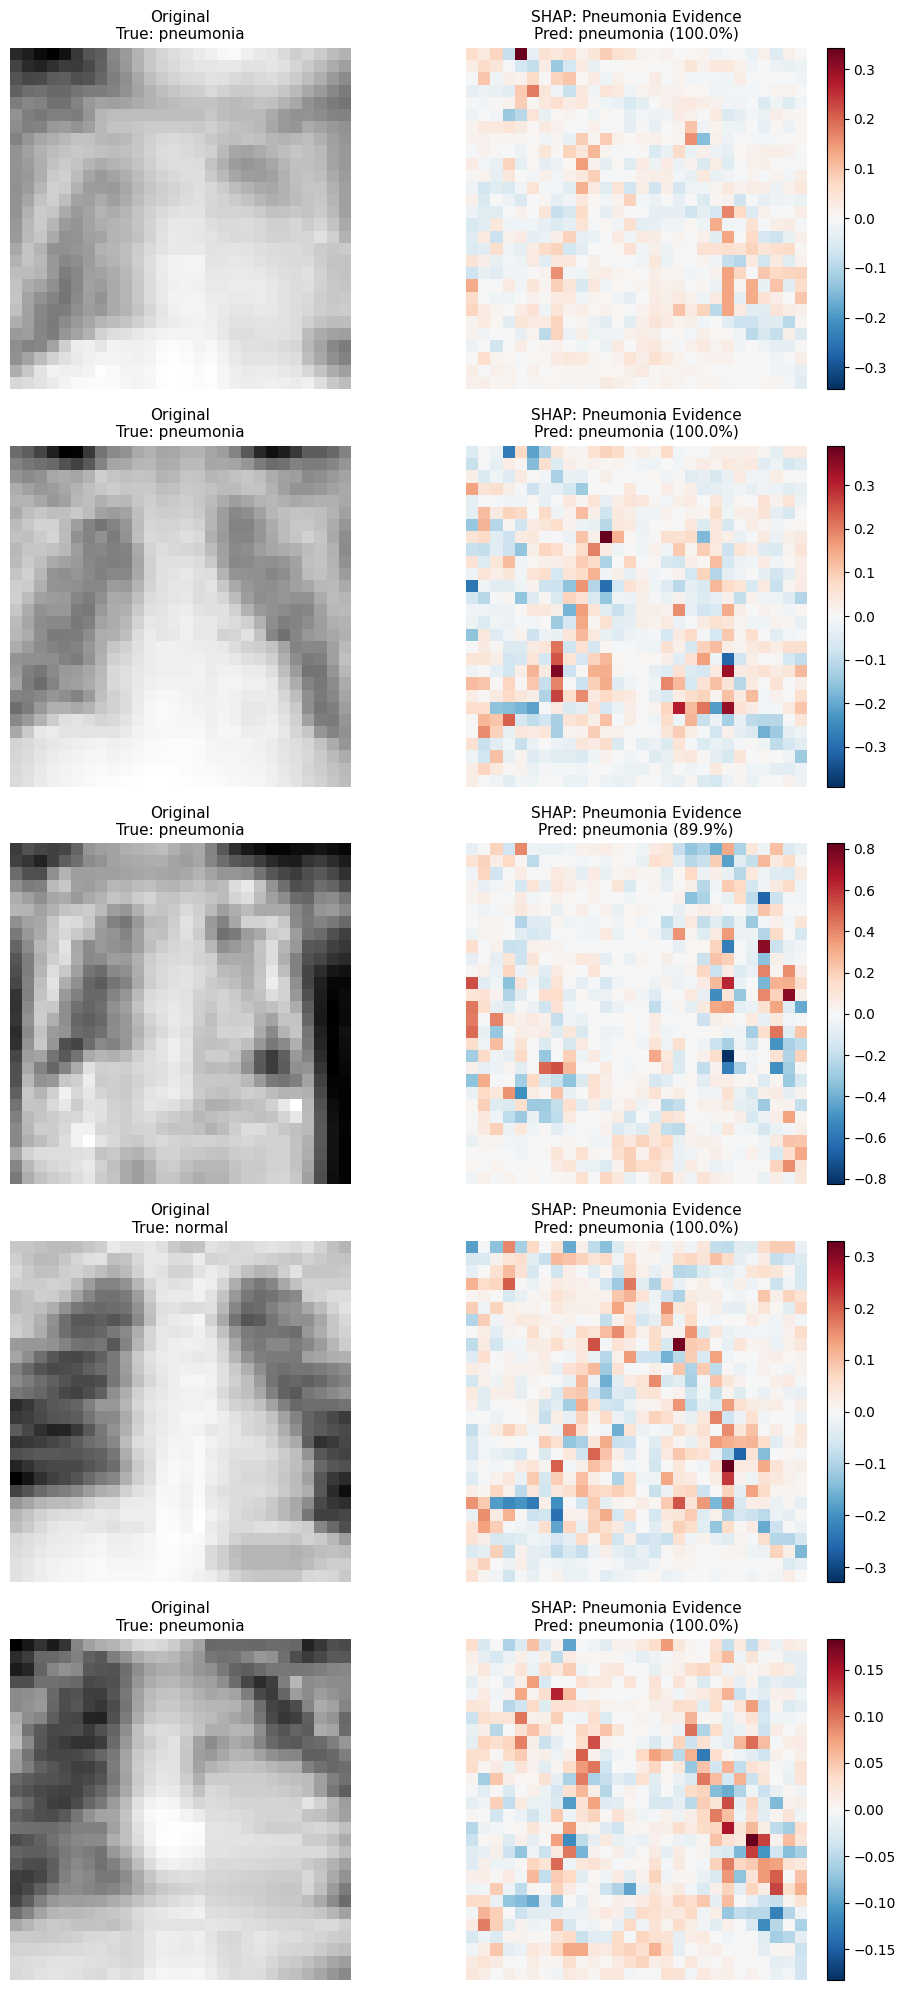


SHAP Analysis Complete!


In [19]:
# SHAP EXPLAINABILITY (FINAL - MY STYLE)
# PneumoniaMNIST + ResNet18 + Grayscale + GradientExplainer
# This version handles SHAP output shape like: (N, 1, H, W, 2)

import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

print("=" * 60)
print("SHAP EXPLAINABILITY ANALYSIS")
print("=" * 60)

# I set the model to evaluation mode (no training updates).
model.eval()

# 1) Get a batch of images from the test loader

batch = next(iter(test_loader))
images, labels = batch

# I choose some images as background for SHAP (baseline/reference).
# Background does NOT need to be big. 50-100 is enough.
background = images[:100].to(device)

# I choose a small set of images to explain with SHAP.
test_images = images[100:105].to(device)
test_labels = labels[100:105]

print(f"\nAnalyzing {len(test_images)} test images")

# 2) Prepare original images for plotting

# The test_images tensor shape is (N, 1, H, W).
# SHAP image plotting for grayscale expects (N, H, W).
test_numpy = test_images.detach().cpu().numpy()
test_numpy = np.squeeze(test_numpy, axis=1)

# 3) Initialize SHAP GradientExplainer

print("Initializing SHAP GradientExplainer...")
explainer = shap.GradientExplainer(model, background)

# 4) Compute SHAP values

print("Computing SHAP values (this may take a moment)...")
shap_values = explainer.shap_values(test_images)

# 5) Convert SHAP output to numpy safely

# Sometimes SHAP returns a list, sometimes it returns a tensor/ndarray.
# I want a numpy array at the end.
if isinstance(shap_values, list):
    
    shap_list = []
    
    for x in shap_values:
        
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        
        shap_list.append(x)
    
    shap_arr = np.array(shap_list)

else:
    
    shap_arr = shap_values
    
    if isinstance(shap_arr, torch.Tensor):
        shap_arr = shap_arr.detach().cpu().numpy()

print("\nRaw SHAP array shape:", shap_arr.shape)

# 6) Select Pneumonia class and fix SHAP shape for plotting

# In many cases, SHAP returns shape like: (N, 1, H, W, 2)
# The last dimension (2) is the number of classes.
# I select class index 1 (Pneumonia) -> shape becomes (N, 1, H, W).
if shap_arr.ndim == 5 and shap_arr.shape[-1] == 2:
    
    shap_pneumonia = shap_arr[..., 1]

else:
    
    shap_pneumonia = shap_arr

print("After class selection shape:", shap_pneumonia.shape)

# Now I remove the channel dimension if it exists:
# (N, 1, H, W) -> (N, H, W)
if shap_pneumonia.ndim == 4 and shap_pneumonia.shape[1] == 1:
    
    shap_pneumonia = shap_pneumonia[:, 0, :, :]

# Another possible case:
# (N, H, W, 1) -> (N, H, W)
if shap_pneumonia.ndim == 4 and shap_pneumonia.shape[-1] == 1:
    
    shap_pneumonia = shap_pneumonia[:, :, :, 0]

print("Final SHAP shape for plotting:", shap_pneumonia.shape)
print("Final image shape for plotting:", test_numpy.shape)

# 7) Global SHAP visualization

print("\nGenerating SHAP visualization...")
print("Red = supports Pneumonia prediction")
print("Blue = opposes Pneumonia prediction")

# shap.image_plot expects a LIST of explanations (even if we plot only one).
shap.image_plot([shap_pneumonia], test_numpy)

# DETAILED CASE-BY-CASE ANALYSIS (Original + SHAP)

print("\n" + "=" * 60)
print("DETAILED CASE ANALYSIS")
print("=" * 60)

# I compute predictions and probabilities for these test images.
with torch.no_grad():
    
    outputs = model(test_images)
    
    probabilities = torch.softmax(outputs, dim=1)
    
    predictions = outputs.argmax(dim=1)

# I create a figure with 2 columns:
# Column 1: Original image
# Column 2: SHAP (Pneumonia evidence)
fig, axes = plt.subplots(len(test_images), 2, figsize=(10, 4 * len(test_images)))

# If we only have 1 image, I reshape axes to keep indexing consistent.
if len(test_images) == 1:
    axes = axes.reshape(1, -1)

for i in range(len(test_images)):
    
    img = test_numpy[i]
    shap_map = shap_pneumonia[i]
    
    true_label = int(test_labels[i].item())
    pred_label = int(predictions[i].item())
    
    confidence = float(probabilities[i, pred_label].item() * 100)
    
    true_name = info["label"][str(true_label)]
    pred_name = info["label"][str(pred_label)]
    
    is_correct = (true_label == pred_label)

    # --- Plot: Original ---
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Original\nTrue: {true_name}", fontsize=11)
    axes[i, 0].axis("off")

    # --- Plot: SHAP ---
    im = axes[i, 1].imshow(
        shap_map,
        cmap="RdBu_r",
        vmin=-np.abs(shap_map).max(),
        vmax=np.abs(shap_map).max()
    )
    
    axes[i, 1].set_title(
        f"SHAP: Pneumonia Evidence\nPred: {pred_name} ({confidence:.1f}%)",
        fontsize=11
    )
    
    axes[i, 1].axis("off")
    
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # --- Print a short interpretation ---
    print(f"\nCase {i+1}:")
    print(f"  True label: {true_name}")
    print(f"  Predicted: {pred_name} ({confidence:.2f}%)")
    print(f"  Result: {'Correct' if is_correct else 'Incorrect'}")
    
    if is_correct and pred_label == 1:
        print("  - Red areas = evidence supporting Pneumonia.")
    elif is_correct and pred_label == 0:
        print("  - Mostly blue/neutral = evidence against Pneumonia.")
    else:
        print("  - Misclassified case: SHAP may highlight confusing regions.")

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SHAP Analysis Complete!")
print("=" * 60)


SHAP EXPLAINABILITY ANALYSIS (MORE CASES)

Target cases:
  TP (Pneumonia correct): 3
  TN (Normal correct):    3
  FP (Normal -> Pneum):   2
  FN (Pneum -> Normal):   2
  Total to explain:       10

Collected cases:
  TP collected: 3
  TN collected: 3
  FP collected: 2
  FN collected: 2

Final selected images: 10

Initializing SHAP GradientExplainer...
Computing SHAP values (this may take a moment)...

Raw SHAP array shape: (10, 1, 28, 28, 2)
After class selection shape: (10, 1, 28, 28)
Final SHAP shape for plotting: (10, 28, 28)
Final image shape for plotting: (10, 28, 28)

Generating SHAP visualization...
Red = supports Pneumonia prediction
Blue = opposes Pneumonia prediction


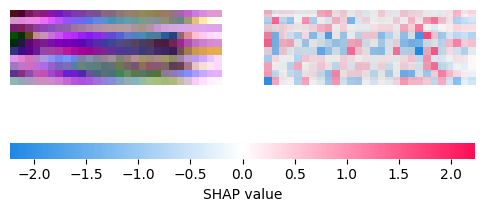


DETAILED CASE ANALYSIS

Case 1:
  True label: pneumonia
  Predicted: pneumonia (100.00%)
  Result: Correct
  - Red regions indicate evidence supporting Pneumonia.

Case 2:
  True label: pneumonia
  Predicted: pneumonia (98.73%)
  Result: Correct
  - Red regions indicate evidence supporting Pneumonia.

Case 3:
  True label: pneumonia
  Predicted: pneumonia (100.00%)
  Result: Correct
  - Red regions indicate evidence supporting Pneumonia.

Case 4:
  True label: normal
  Predicted: normal (100.00%)
  Result: Correct
  - Blue/neutral regions indicate evidence against Pneumonia.

Case 5:
  True label: normal
  Predicted: normal (99.78%)
  Result: Correct
  - Blue/neutral regions indicate evidence against Pneumonia.

Case 6:
  True label: normal
  Predicted: normal (100.00%)
  Result: Correct
  - Blue/neutral regions indicate evidence against Pneumonia.

Case 7:
  True label: normal
  Predicted: pneumonia (99.89%)
  Result: Incorrect
  - Misclassified: SHAP may highlight confusing or misle

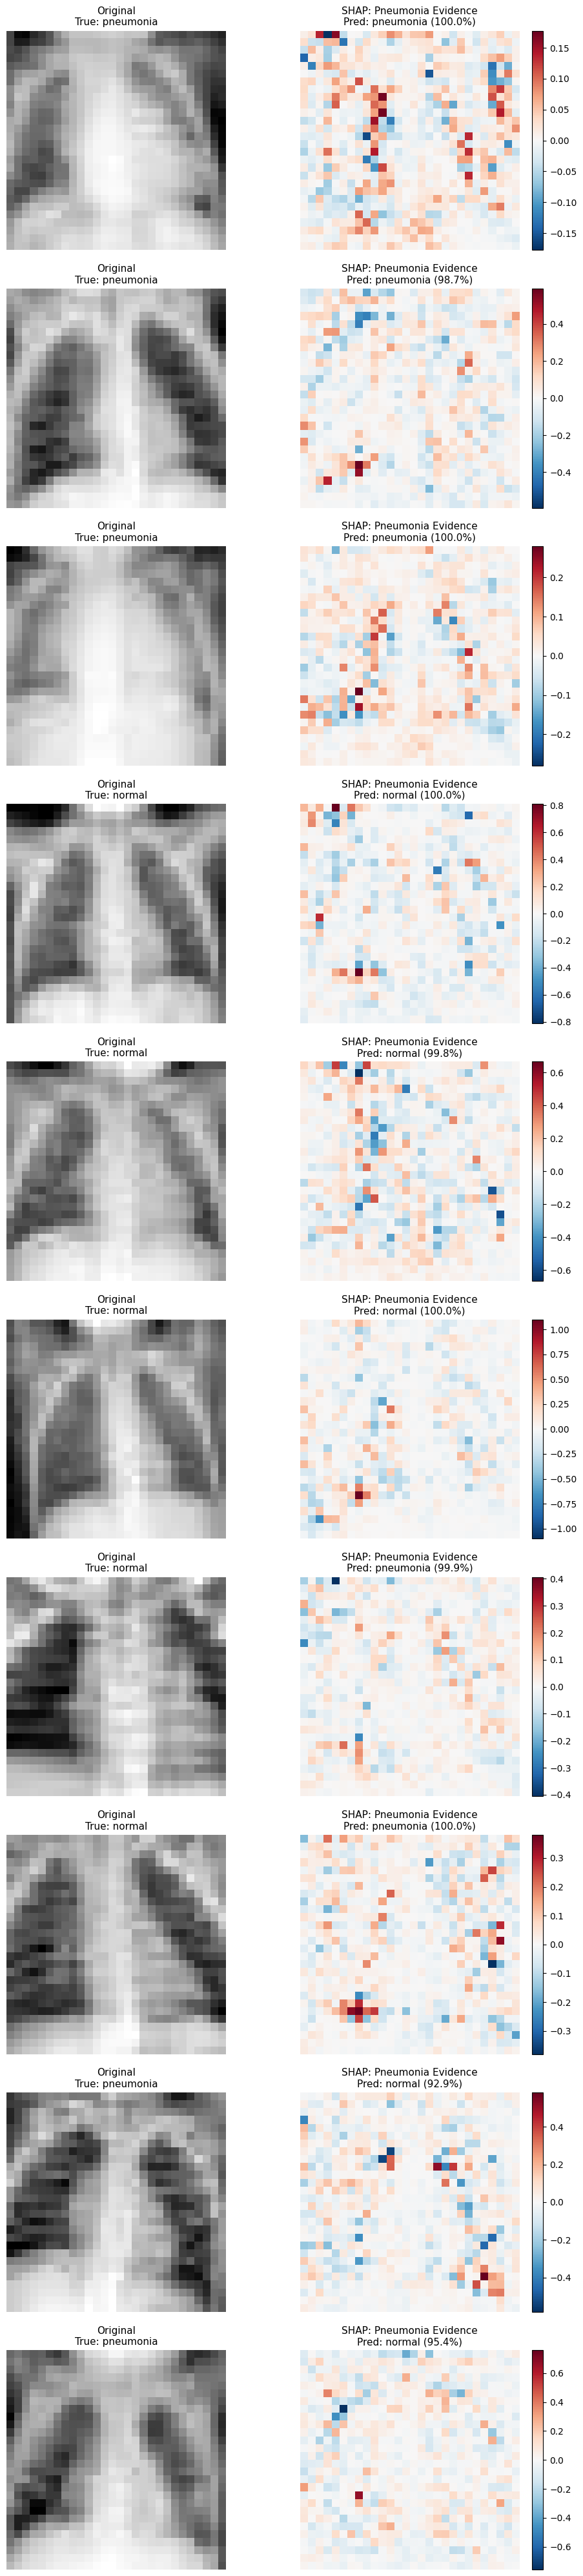


SHAP Analysis Complete!


In [20]:
# ============================================================================
# SHAP EXPLAINABILITY (FINAL - MORE CASES - MY STYLE)
# Auto-select: Correct + Incorrect from BOTH classes
# Works with SHAP output shape: (N, 1, H, W, 2)
# ============================================================================

import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

print("=" * 60)
print("SHAP EXPLAINABILITY ANALYSIS (MORE CASES)")
print("=" * 60)

# I set the model to evaluation mode.
model.eval()

# ----------------------------------------------------------------------------
# 1) I choose how many cases I want from each category
# ----------------------------------------------------------------------------

# You can increase these numbers if you want more examples.
N_TP = 3  # True Positive  (Pneumonia predicted Pneumonia)  ✅
N_TN = 3  # True Negative  (Normal predicted Normal)        ✅
N_FP = 2  # False Positive (Normal predicted Pneumonia)     ❌
N_FN = 2  # False Negative (Pneumonia predicted Normal)     ❌

# Total images that we will explain with SHAP
N_TOTAL = N_TP + N_TN + N_FP + N_FN

print("\nTarget cases:")
print(f"  TP (Pneumonia correct): {N_TP}")
print(f"  TN (Normal correct):    {N_TN}")
print(f"  FP (Normal -> Pneum):   {N_FP}")
print(f"  FN (Pneum -> Normal):   {N_FN}")
print(f"  Total to explain:       {N_TOTAL}")

# ----------------------------------------------------------------------------
# 2) I collect cases from the test set automatically
# ----------------------------------------------------------------------------

tp_images, tp_labels = [], []
tn_images, tn_labels = [], []
fp_images, fp_labels = [], []
fn_images, fn_labels = [], []

# I will loop over the test_loader and collect samples until I have enough.
with torch.no_grad():

    for batch_images, batch_labels in test_loader:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device).squeeze().long()

        outputs = model(batch_images)
        preds = outputs.argmax(dim=1)

        for j in range(batch_images.size(0)):

            x = batch_images[j].detach().cpu()
            y = int(batch_labels[j].item())
            p = int(preds[j].item())

            # Class mapping:
            # 0 = normal
            # 1 = pneumonia

            # TP: y=1 and p=1
            if y == 1 and p == 1 and len(tp_images) < N_TP:
                tp_images.append(x)
                tp_labels.append(y)

            # TN: y=0 and p=0
            elif y == 0 and p == 0 and len(tn_images) < N_TN:
                tn_images.append(x)
                tn_labels.append(y)

            # FP: y=0 and p=1
            elif y == 0 and p == 1 and len(fp_images) < N_FP:
                fp_images.append(x)
                fp_labels.append(y)

            # FN: y=1 and p=0
            elif y == 1 and p == 0 and len(fn_images) < N_FN:
                fn_images.append(x)
                fn_labels.append(y)

            # Stop early if we have everything
            if (len(tp_images) == N_TP and len(tn_images) == N_TN and
                len(fp_images) == N_FP and len(fn_images) == N_FN):
                break

        if (len(tp_images) == N_TP and len(tn_images) == N_TN and
            len(fp_images) == N_FP and len(fn_images) == N_FN):
            break

print("\nCollected cases:")
print(f"  TP collected: {len(tp_images)}")
print(f"  TN collected: {len(tn_images)}")
print(f"  FP collected: {len(fp_images)}")
print(f"  FN collected: {len(fn_images)}")

# If the dataset/model does not produce enough FP/FN, we still continue with what we have.
selected_images = tp_images + tn_images + fp_images + fn_images
selected_labels = tp_labels + tn_labels + fp_labels + fn_labels

print(f"\nFinal selected images: {len(selected_images)}")

# Convert list of tensors to a single tensor: (N, 1, 28, 28)
test_images = torch.stack(selected_images, dim=0).to(device)
test_labels = torch.tensor(selected_labels)

# ----------------------------------------------------------------------------
# 3) Background data for SHAP
# ----------------------------------------------------------------------------

# I take a background batch from test_loader (fast + enough for SHAP)
bg_images, _ = next(iter(test_loader))
background = bg_images[:100].to(device)

# ----------------------------------------------------------------------------
# 4) Prepare original images for plotting
# ----------------------------------------------------------------------------

test_numpy = test_images.detach().cpu().numpy()
test_numpy = np.squeeze(test_numpy, axis=1)  # (N, 28, 28)

# ----------------------------------------------------------------------------
# 5) Initialize SHAP GradientExplainer and compute SHAP values
# ----------------------------------------------------------------------------

print("\nInitializing SHAP GradientExplainer...")
explainer = shap.GradientExplainer(model, background)

print("Computing SHAP values (this may take a moment)...")
shap_values = explainer.shap_values(test_images)

# ----------------------------------------------------------------------------
# 6) Convert SHAP output to numpy safely
# ----------------------------------------------------------------------------

if isinstance(shap_values, list):

    shap_list = []

    for x in shap_values:

        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()

        shap_list.append(x)

    shap_arr = np.array(shap_list)

else:

    shap_arr = shap_values

    if isinstance(shap_arr, torch.Tensor):
        shap_arr = shap_arr.detach().cpu().numpy()

print("\nRaw SHAP array shape:", shap_arr.shape)

# ----------------------------------------------------------------------------
# 7) Select Pneumonia class (index 1) and fix shape -> (N, 28, 28)
# ----------------------------------------------------------------------------

# Common shape: (N, 1, H, W, 2)
if shap_arr.ndim == 5 and shap_arr.shape[-1] == 2:

    shap_pneumonia = shap_arr[..., 1]  # (N, 1, H, W)

else:

    shap_pneumonia = shap_arr

print("After class selection shape:", shap_pneumonia.shape)

# Remove channel dim: (N, 1, H, W) -> (N, H, W)
if shap_pneumonia.ndim == 4 and shap_pneumonia.shape[1] == 1:
    shap_pneumonia = shap_pneumonia[:, 0, :, :]

# Remove trailing single channel: (N, H, W, 1) -> (N, H, W)
if shap_pneumonia.ndim == 4 and shap_pneumonia.shape[-1] == 1:
    shap_pneumonia = shap_pneumonia[:, :, :, 0]

print("Final SHAP shape for plotting:", shap_pneumonia.shape)
print("Final image shape for plotting:", test_numpy.shape)

# ----------------------------------------------------------------------------
# 8) Global SHAP visualization
# ----------------------------------------------------------------------------

print("\nGenerating SHAP visualization...")
print("Red = supports Pneumonia prediction")
print("Blue = opposes Pneumonia prediction")

shap.image_plot([shap_pneumonia], test_numpy)

# ============================================================================
# DETAILED CASE-BY-CASE ANALYSIS
# ============================================================================

print("\n" + "=" * 60)
print("DETAILED CASE ANALYSIS")
print("=" * 60)

# I compute predictions and confidence for these selected images
with torch.no_grad():

    outputs = model(test_images)
    probabilities = torch.softmax(outputs, dim=1)
    predictions = outputs.argmax(dim=1)

# I create a figure: Original + SHAP
fig, axes = plt.subplots(len(test_images), 2, figsize=(10, 4 * len(test_images)))
if len(test_images) == 1:
    axes = axes.reshape(1, -1)

for i in range(len(test_images)):

    img = test_numpy[i]
    shap_map = shap_pneumonia[i]

    true_label = int(test_labels[i].item())
    pred_label = int(predictions[i].item())

    confidence = float(probabilities[i, pred_label].item() * 100)

    true_name = info["label"][str(true_label)]
    pred_name = info["label"][str(pred_label)]

    is_correct = (true_label == pred_label)

    # --- Original image ---
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Original\nTrue: {true_name}", fontsize=11)
    axes[i, 0].axis("off")

    # --- SHAP map (Pneumonia evidence) ---
    im = axes[i, 1].imshow(
        shap_map,
        cmap="RdBu_r",
        vmin=-np.abs(shap_map).max(),
        vmax=np.abs(shap_map).max()
    )

    axes[i, 1].set_title(
        f"SHAP: Pneumonia Evidence\nPred: {pred_name} ({confidence:.1f}%)",
        fontsize=11
    )

    axes[i, 1].axis("off")
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # --- Print analysis ---
    print(f"\nCase {i+1}:")
    print(f"  True label: {true_name}")
    print(f"  Predicted: {pred_name} ({confidence:.2f}%)")
    print(f"  Result: {'Correct' if is_correct else 'Incorrect'}")

    if is_correct and pred_label == 1:
        print("  - Red regions indicate evidence supporting Pneumonia.")
    elif is_correct and pred_label == 0:
        print("  - Blue/neutral regions indicate evidence against Pneumonia.")
    else:
        print("  - Misclassified: SHAP may highlight confusing or misleading regions.")

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SHAP Analysis Complete!")
print("=" * 60)


## Final Thoughts

I have now completed the entire pipeline. I started by loading and preparing the data. Then I modified a ResNet18 model and trained it on the images. Finally, I used SHAP to explain the predictions. This process showed me that the model works well and looks at relevant features in the X-rays. It was a great learning experience to see how deep learning can be applied to medical imaging.